Carga de datos y objetivo

Cargamos el dataset de licitaciones, definimos la variable objetivo a partir del importe de adjudicación y dividimos en train/test (80/20) sin tocar test hasta la evaluación final.

In [1]:
import warnings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=UserWarning)

df = pd.read_parquet("src/data_sample/datos_licitaciones.parquet")
print("Shape:", df.shape)
df.head()

Shape: (37700, 35)


,Situació contractual,Exercici,Àmbit organitzatiu,Identificador agrupació organisme,Agrupació organisme,Identificador organisme contractant,Organisme contractant,Codi de l’expedient,Procediment d’adjudicació,Tipus de contracte,...,Tipus de modificació,Import de la modificació,Data aprovació modificació,Termini modificació anys,Termini modificació mesos,Termini modificació dies,Tipus de liquidació,Data de liquidació,Causa de resolució,Import de la liquidació
572837,liquidació,2022,Entitats de l'Administració Local,4316280001,Ajuntament de Vandellòs i l'Hospitalet de l'In...,4316280001,Ajuntament de Vandellòs i l'Hospitalet de l'In...,0225 / 2022,Menor,3. SUBMINISTRAMENTS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,08/02/2022,,2.38
609033,liquidació,2023,Departaments i Sector Públic de la Generalitat...,1500,DEPARTAMENT DE SALUT,1542,Institut Català de la Salut (ICS) Barcelonès H...,1101369832,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,14/11/2023,,170.68
1612984,liquidació,2024,Entitats de l'Administració Local,0822050006,Ajuntament de Sant Julià de Vilatorta,0822050006,Ajuntament de Sant Julià de Vilatorta,SU41,Menor,3. SUBMINISTRAMENTS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,13/05/2024,,45.81
1412433,liquidació,2021,Departaments i Sector Públic de la Generalitat...,1400,DEPARTAMENT DE CULTURA,7915100002,Biblioteca de Catalunya,BC-2021-135,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,15/06/2021,,2150.13
951405,liquidació,2025,Entitats de l'Administració Local,8000840003,Diputació de Barcelona,8000840003,Diputació de Barcelona,2025/4118 - 9,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,25/03/2025,,880.00


In [20]:
df = pd.read_parquet("src/data_sample/datos_licitaciones.parquet")

print("Filas, columnas:", df.shape)
display(df.head())
display(df.columns)

Filas, columnas: (37700, 35)


,Situació contractual,Exercici,Àmbit organitzatiu,Identificador agrupació organisme,Agrupació organisme,Identificador organisme contractant,Organisme contractant,Codi de l’expedient,Procediment d’adjudicació,Tipus de contracte,...,Tipus de modificació,Import de la modificació,Data aprovació modificació,Termini modificació anys,Termini modificació mesos,Termini modificació dies,Tipus de liquidació,Data de liquidació,Causa de resolució,Import de la liquidació
572837,liquidació,2022,Entitats de l'Administració Local,4316280001,Ajuntament de Vandellòs i l'Hospitalet de l'In...,4316280001,Ajuntament de Vandellòs i l'Hospitalet de l'In...,0225 / 2022,Menor,3. SUBMINISTRAMENTS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,08/02/2022,,2.38
609033,liquidació,2023,Departaments i Sector Públic de la Generalitat...,1500,DEPARTAMENT DE SALUT,1542,Institut Català de la Salut (ICS) Barcelonès H...,1101369832,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,14/11/2023,,170.68
1612984,liquidació,2024,Entitats de l'Administració Local,0822050006,Ajuntament de Sant Julià de Vilatorta,0822050006,Ajuntament de Sant Julià de Vilatorta,SU41,Menor,3. SUBMINISTRAMENTS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,13/05/2024,,45.81
1412433,liquidació,2021,Departaments i Sector Públic de la Generalitat...,1400,DEPARTAMENT DE CULTURA,7915100002,Biblioteca de Catalunya,BC-2021-135,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,15/06/2021,,2150.13
951405,liquidació,2025,Entitats de l'Administració Local,8000840003,Diputació de Barcelona,8000840003,Diputació de Barcelona,2025/4118 - 9,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,25/03/2025,,880.00


Index(['Situació contractual', 'Exercici', 'Àmbit organitzatiu',
       'Identificador agrupació organisme', 'Agrupació organisme',
       'Identificador organisme contractant', 'Organisme contractant',
       'Codi de l’expedient', 'Procediment d’adjudicació',
       'Tipus de contracte', 'Descripció de l’expedient', 'Número de lot',
       'Codi CPV', 'Adjudicatari', 'Import d’adjudicació',
       'Data d’adjudicació', 'Descripció del lot', 'Lot desert', 'Durada dies',
       'Durada mesos', 'Durada anys', 'Número de pròrroga',
       'Data inici pròrroga', 'Data fi pròrroga', 'Número de modificació',
       'Tipus de modificació', 'Import de la modificació',
       'Data aprovació modificació', 'Termini modificació anys',
       'Termini modificació mesos', 'Termini modificació dies',
       'Tipus de liquidació', 'Data de liquidació', 'Causa de resolució',
       'Import de la liquidació'],
      dtype='object')

In [ ]:
# Columna de importe de adjudicación 
importe_col = [c for c in df.columns if "Import" in c and "adjudicació" in c][0]
df[importe_col] = pd.to_numeric(df[importe_col], errors="coerce")
df = df.dropna(subset=[importe_col])

# Target binario: 1 si importe > mediana, 0 si no 
mediana = df[importe_col].median()
df["gasto_alto"] = (df[importe_col] > mediana).astype(int)
print("Mediana importe:", mediana)
print("Distribución gasto_alto:", df["gasto_alto"].value_counts().to_dict())

Mediana importe: 482.1
Distribución gasto_alto: {0: 18850, 1: 18850}


In [3]:
train, test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["gasto_alto"]
)
print("Train:", train.shape, "Test:", test.shape)

Train: (30160, 36) Test: (7540, 36)


Tipos, cardinalidad de categóricas y % de missings por columna (en train).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df = pd.read_parquet("src/data_sample/datos_licitaciones.parquet")

print("Filas, columnas:", df.shape)
display(df.head())
display(df.columns)

Filas, columnas: (37700, 35)


,Situació contractual,Exercici,Àmbit organitzatiu,Identificador agrupació organisme,Agrupació organisme,Identificador organisme contractant,Organisme contractant,Codi de l’expedient,Procediment d’adjudicació,Tipus de contracte,...,Tipus de modificació,Import de la modificació,Data aprovació modificació,Termini modificació anys,Termini modificació mesos,Termini modificació dies,Tipus de liquidació,Data de liquidació,Causa de resolució,Import de la liquidació
572837,liquidació,2022,Entitats de l'Administració Local,4316280001,Ajuntament de Vandellòs i l'Hospitalet de l'In...,4316280001,Ajuntament de Vandellòs i l'Hospitalet de l'In...,0225 / 2022,Menor,3. SUBMINISTRAMENTS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,08/02/2022,,2.38
609033,liquidació,2023,Departaments i Sector Públic de la Generalitat...,1500,DEPARTAMENT DE SALUT,1542,Institut Català de la Salut (ICS) Barcelonès H...,1101369832,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,14/11/2023,,170.68
1612984,liquidació,2024,Entitats de l'Administració Local,0822050006,Ajuntament de Sant Julià de Vilatorta,0822050006,Ajuntament de Sant Julià de Vilatorta,SU41,Menor,3. SUBMINISTRAMENTS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,13/05/2024,,45.81
1412433,liquidació,2021,Departaments i Sector Públic de la Generalitat...,1400,DEPARTAMENT DE CULTURA,7915100002,Biblioteca de Catalunya,BC-2021-135,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,15/06/2021,,2150.13
951405,liquidació,2025,Entitats de l'Administració Local,8000840003,Diputació de Barcelona,8000840003,Diputació de Barcelona,2025/4118 - 9,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,25/03/2025,,880.00


Index(['Situació contractual', 'Exercici', 'Àmbit organitzatiu',
       'Identificador agrupació organisme', 'Agrupació organisme',
       'Identificador organisme contractant', 'Organisme contractant',
       'Codi de l’expedient', 'Procediment d’adjudicació',
       'Tipus de contracte', 'Descripció de l’expedient', 'Número de lot',
       'Codi CPV', 'Adjudicatari', 'Import d’adjudicació',
       'Data d’adjudicació', 'Descripció del lot', 'Lot desert', 'Durada dies',
       'Durada mesos', 'Durada anys', 'Número de pròrroga',
       'Data inici pròrroga', 'Data fi pròrroga', 'Número de modificació',
       'Tipus de modificació', 'Import de la modificació',
       'Data aprovació modificació', 'Termini modificació anys',
       'Termini modificació mesos', 'Termini modificació dies',
       'Tipus de liquidació', 'Data de liquidació', 'Causa de resolució',
       'Import de la liquidació'],
      dtype='object')

In [ ]:
# intenta detectar la columna de importe automáticamente
posibles_columnas = [c for c in df.columns if "import" in c.lower() or "amount" in c.lower() or "euros" in c.lower()]
print("Posibles columnas de importe:", posibles_columnas)

if len(posibles_columnas) > 0:
    importe_columna = posibles_columnas[0]
else:
    importe_columna = None

importe_columna

Posibles columnas de importe: ['Import d’adjudicació', 'Import de la modificació', 'Import de la liquidació']


'Import d’adjudicació'

In [ ]:
importe_columna = "Import d’adjudicació"

In [ ]:
#Convierte la columna del dinero a números reales
df[importe_columna] = pd.to_numeric(df[importe_columna], errors="coerce")

#Borra las filas donde el importe está vacío
df = df.dropna(subset=[importe_columna])

#Dame un resumen del dinero
print(df[importe_columna].describe())

#Enséñame las primeras filas de esa columna
df[[importe_columna]].head()

count    3.770000e+04
mean     2.919447e+03
std      3.186843e+04
min     -3.570100e+02
25%      1.478175e+02
50%      4.821000e+02
75%      1.647405e+03
max      3.713358e+06
Name: Import d’adjudicació, dtype: float64


,Import d’adjudicació
572837,2.38
609033,170.68
1612984,45.81
1412433,2150.13
951405,880.00


In [ ]:
# calcular la mediana del importe
umbral = df[importe_columna].median()
print("Umbral del gasto:", umbral)

# crear variable objetivo
df["gasto_alto"] = (df[importe_columna] > umbral).astype(int)

# mirar primeras filas
df[[importe_columna, "gasto_alto"]].head()

Umbral del gasto: 482.1


,Import d’adjudicació,gasto_alto
572837,2.38,0
609033,170.68,0
1612984,45.81,0
1412433,2150.13,1
951405,880.00,1


In [ ]:
df["gasto_alto"].value_counts()

gasto_alto
0    18850
1    18850
Name: count, dtype: int64

In [ ]:
df["gasto_alto"].value_counts(normalize=True)

gasto_alto
0    0.5
1    0.5
Name: proportion, dtype: float64

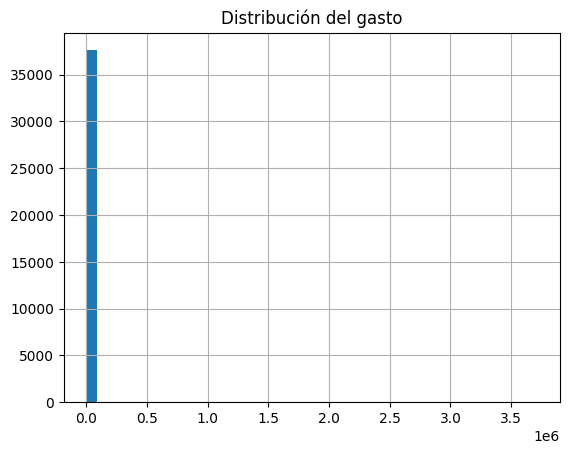

In [ ]:
plt.figure()
df[importe_columna].hist(bins=40)
plt.title("Distribución del gasto")
plt.show()

El histograma muestra muchos gastos pequeños lo que significa que hay una distribución muy sesgada con miles de pagos pequeños y pocos contratos millonarios. Este patrón es habitual en datos de contratación pública, ya que se realizan muchos pagos pequeños y unos pocos contratos de gran cuantía.

In [ ]:
train, test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["gasto_alto"])

print(train.shape, test.shape)

(30160, 36) (7540, 36)


Train tiene 30.160 filas
Test tiene 7.540 filas
Cada uno tiene 36 columnas

In [ ]:
# quitamos target y columna de importe
X_train = train.drop(columns=["gasto_alto", importe_columna])
y_train = train["gasto_alto"]

X_test = test.drop(columns=["gasto_alto", importe_columna])
y_test = test["gasto_alto"]

# nos quedamos solo con numéricas 
X_train = X_train.select_dtypes(include="number")
X_test = X_test[X_train.columns]

print("Columnas usadas:", len(X_train.columns))

Columnas usadas: 12


Nos hemos quedado con 12 columnas numéricas

In [ ]:
modelo = RandomForest - REGRESSOR 
    random_state=42,
    n_estimators=200,
    class_weight="balanced")


modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)

In [ ]:
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3770
           1       1.00      1.00      1.00      3770

    accuracy                           1.00      7540
   macro avg       1.00      1.00      1.00      7540
weighted avg       1.00      1.00      1.00      7540

[[3764    6]
 [   5 3765]]


El modelo presenta un rendimiento muy alto y comete muy pocos errores. Clasifica correctamente casi todos los gastos, lo que sugiere que las variables utilizadas contienen información suficiente para diferenciar entre gastos altos y bajos.

3764 gastos normales 
3765 gastos altos 
solo 11 errores en total (6 predicho alto +5 predicho normal)
De más de 7500 casos.

In [ ]:
cm = confusion_matrix(y_test, pred)
errores = cm.sum() - np.trace(cm)
errores

np.int64(11)

La matriz de confusión muestra que el modelo solo comete 11 errores sobre más de 7.500 casos evaluados.

In [ ]:
importancias = pd.Series(modelo.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False)

importancias.head(10)

Import de la liquidació     0.955148
Durada mesos                0.023491
Durada dies                 0.014528
Durada anys                 0.005038
Exercici                    0.001183
Número de lot               0.000611
Número de modificació       0.000000
Número de pròrroga          0.000000
Import de la modificació    0.000000
Termini modificació anys    0.000000
dtype: float64

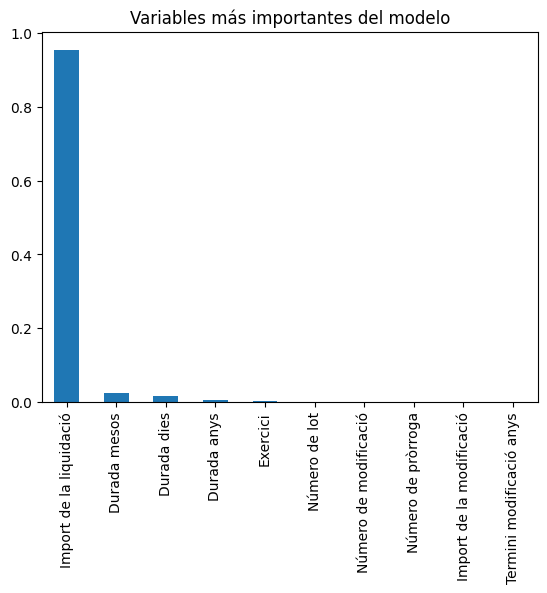

In [ ]:
importancias.head(10).plot(kind="bar")
plt.title("Variables más importantes del modelo")
plt.show()

El análisis de importancia de variables muestra que el modelo se apoya principalmente en un pequeño número de variables, especialmente en el importe de la liquidación, lo que sugiere que esta contiene gran parte de la información necesaria para clasificar los gastos.

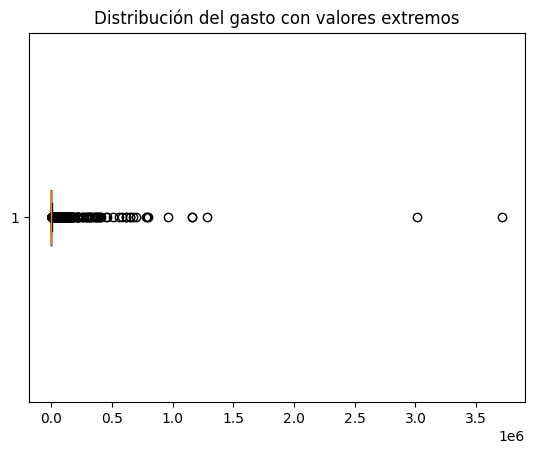

In [ ]:
plt.figure()
plt.boxplot(df[importe_columna], vert=False)
plt.title("Distribución del gasto con valores extremos")
plt.show()

El boxplot muestra que la mayor parte de los gastos son de importe bajo, aunque existen algunos valores muy altos. Esto indica la presencia de outliers, algo habitual en datasets de gasto público.

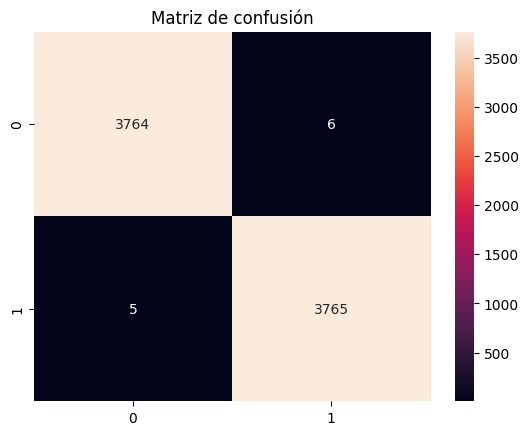

In [ ]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriz de confusión")
plt.show()

La matriz de confusión muestra que el modelo clasifica correctamente casi todos los casos y comete muy pocos errores, lo que indica un rendimiento muy alto.

En este proyecto se ha desarrollado un modelo de Machine Learning para clasificar los gastos públicos de la Administración de Cataluña en gastos altos o normales. Para ello, se utilizó un dataset con más de 37.000 registros y, tras una limpieza básica, se seleccionaron las variables numéricas más relevantes.

El análisis exploratorio mostró que los importes no siguen una distribución uniforme. La mayoría de los gastos son bajos y solo hay algunos valores muy altos, lo que genera una distribución sesgada. Este patrón es bastante habitual en datos de gasto público, donde conviven muchos contratos pequeños con unos pocos de gran importe.

Después se dividieron los datos en entrenamiento y prueba (80/20) y se entrenó un modelo Random Forest con 12 variables numéricas. El modelo obtuvo un rendimiento muy alto en test, clasificando correctamente casi todos los casos y cometiendo solo 11 errores sobre más de 7.500 observaciones.

El análisis de importancia de variables indica que el modelo depende sobre todo del importe de la liquidación. El resto de variables tienen bastante menos peso, lo que sugiere que esa variable concentra la mayor parte de la información necesaria para diferenciar los gastos.

In [4]:
print("Tipos y no nulos (train):")
print(train.dtypes)
print("\n% missings por columna (train):")
pct_missing = (train.isna().sum() / len(train) * 100).sort_values(ascending=False)
print(pct_missing[pct_missing > 0])
cat_cols = train.select_dtypes(include=["object"]).columns
print("\nCardinalidad categóricas (train):")
train[cat_cols].nunique().sort_values(ascending=False)

Tipos y no nulos (train):
Situació contractual                    object
Exercici                                 int64
Àmbit organitzatiu                      object
Identificador agrupació organisme       object
Agrupació organisme                     object
Identificador organisme contractant     object
Organisme contractant                   object
Codi de l’expedient                     object
Procediment d’adjudicació               object
Tipus de contracte                      object
Descripció de l’expedient               object
Número de lot                            int64
Codi CPV                                object
Adjudicatari                            object
Import d’adjudicació                   float64
Data d’adjudicació                      object
Descripció del lot                      object
Lot desert                              object
Durada dies                              int64
Durada mesos                             int64
Durada anys                       

Codi de l’expedient                    29847
Descripció de l’expedient              25511
Descripció del lot                     25511
Adjudicatari                           15442
Codi CPV                                1697
Data de liquidació                      1691
Data d’adjudicació                      1585
Organisme contractant                    852
Identificador organisme contractant      835
Agrupació organisme                      567
Identificador agrupació organisme        565
Procediment d’adjudicació                  8
Causa de resolució                         8
Tipus de contracte                         7
Àmbit organitzatiu                         3
Lot desert                                 2
Tipus de liquidació                        2
Situació contractual                       1
Tipus de modificació                       1
Data fi pròrroga                           1
Data inici pròrroga                        1
Data aprovació modificació                 1
dtype: int

Análisis univariante

Distribuciones de variables numéricas clave en train.

In [5]:
num_cols = train.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if c not in ["gasto_alto"]]
train[num_cols].describe()

,Exercici,Número de lot,Import d’adjudicació,Durada dies,Durada mesos,Durada anys,Número de pròrroga,Número de modificació,Import de la modificació,Termini modificació anys,Termini modificació mesos,Termini modificació dies,Import de la liquidació
count,30160.000000,30160.000000,3.016000e+04,30160.000000,30160.000000,30160.00000,0.0,0.0,0.0,0.0,0.0,0.0,3.016000e+04
mean,2022.554509,1.019430,3.013194e+03,2.969695,0.543468,0.02374,NaN,NaN,NaN,NaN,NaN,NaN,2.920656e+03
std,1.244590,0.673313,3.471550e+04,11.080129,1.879339,0.16297,NaN,NaN,NaN,NaN,NaN,NaN,3.201638e+04
min,2007.000000,1.000000,-3.570100e+02,0.000000,0.000000,0.00000,NaN,NaN,NaN,NaN,NaN,NaN,-3.570100e+02
25%,2021.000000,1.000000,1.465825e+02,0.000000,0.000000,0.00000,NaN,NaN,NaN,NaN,NaN,NaN,1.450600e+02
50%,2022.000000,1.000000,4.821000e+02,0.000000,0.000000,0.00000,NaN,NaN,NaN,NaN,NaN,NaN,4.800000e+02
75%,2023.000000,1.000000,1.645605e+03,1.000000,0.000000,0.00000,NaN,NaN,NaN,NaN,NaN,NaN,1.617818e+03
max,2026.000000,59.000000,3.713358e+06,365.000000,24.000000,4.00000,NaN,NaN,NaN,NaN,NaN,NaN,4.013769e+06


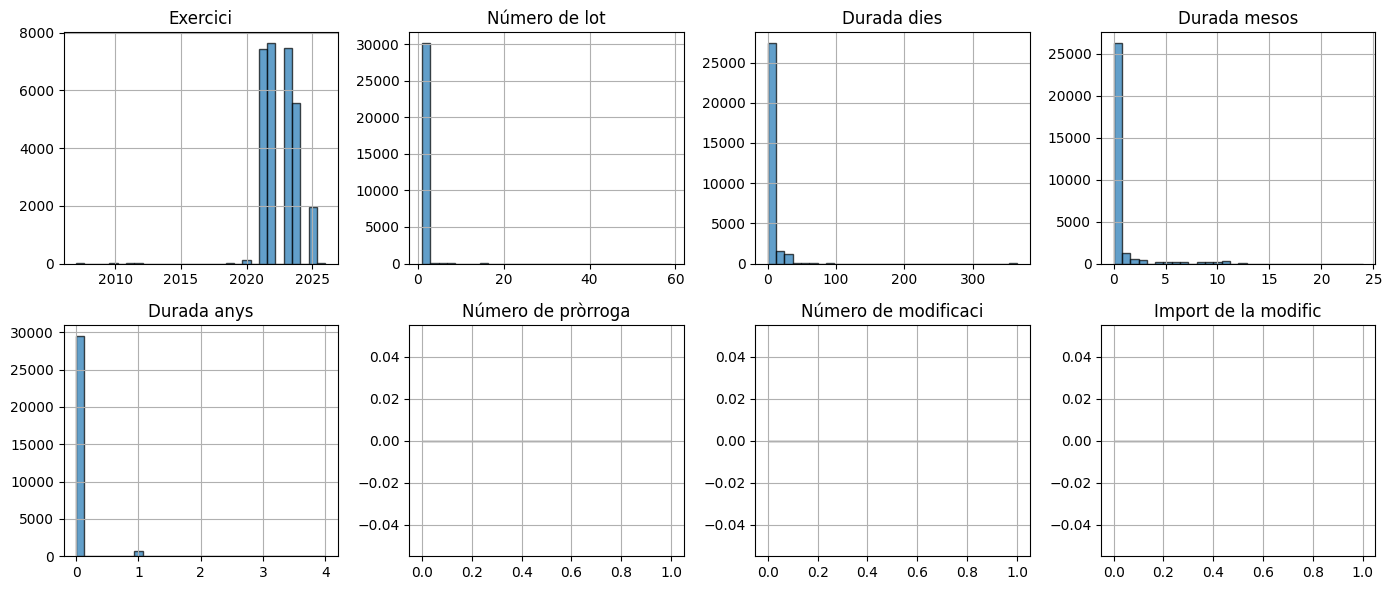

In [6]:
# Variables numéricas sin la columna de importe (para evitar duplicar info del target)
cols_plot = [c for c in num_cols if c != importe_col][:8]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.ravel()
for i, col in enumerate(cols_plot):
    train[col].hist(ax=axes[i], bins=30, edgecolor="black", alpha=0.7)
    axes[i].set_title(col[:20])
plt.tight_layout()
plt.show()

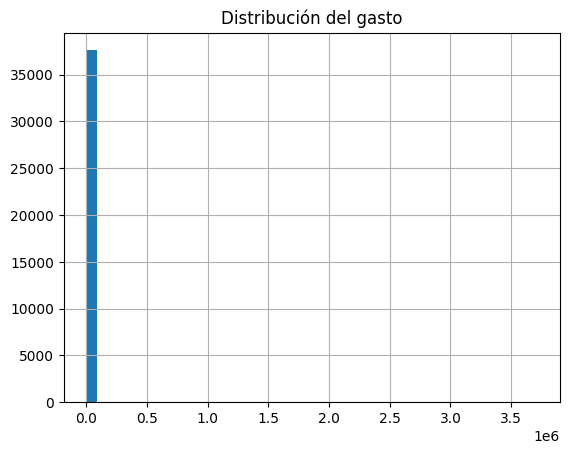

In [27]:
plt.figure()
df[importe_columna].hist(bins=40)
plt.title("Distribución del gasto")
plt.show()

Análisis bivariante

Correlaciones entre numéricas y relación con el target. Excluimos columnas que serían fuga (p. ej. Import de la liquidació si el target se basa en importe de adjudicación).

In [7]:
# Correlación de numéricas con el target (excluyendo importe adjudicación y otras columnas de importe para evitar fuga)
use_num = [c for c in num_cols if c != importe_col and "Import" not in c]
corr_target = train[use_num + ["gasto_alto"]].corr()["gasto_alto"].drop("gasto_alto")
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)
print("Correlación con gasto_alto (train):")
print(corr_target)

Correlación con gasto_alto (train):
Durada mesos                 0.192573
Durada dies                  0.136625
Durada anys                  0.106610
Exercici                     0.022165
Número de lot                0.012804
Número de pròrroga                NaN
Número de modificació             NaN
Termini modificació anys          NaN
Termini modificació mesos         NaN
Termini modificació dies          NaN
Name: gasto_alto, dtype: float64


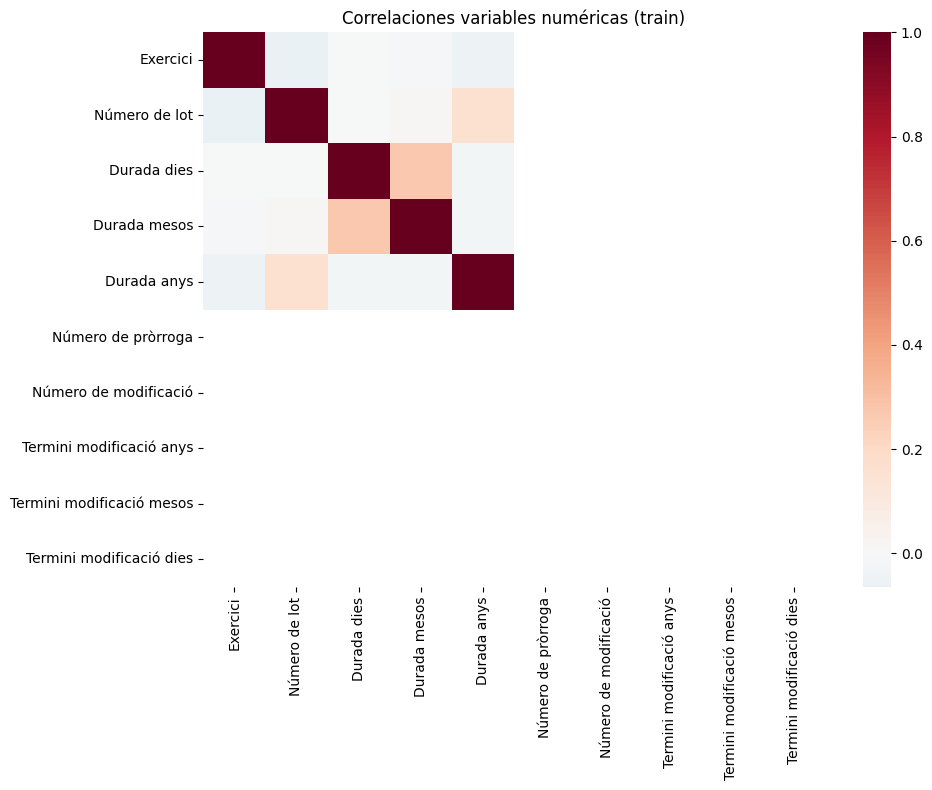

In [8]:
# Matriz de correlación entre numéricas (sin target ni importes para no filtrar por fuga)
mat = train[use_num].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=False, cmap="RdBu_r", center=0)
plt.title("Correlaciones variables numéricas (train)")
plt.tight_layout()
plt.show()

Duplicados

In [9]:
n_dup = train.duplicated().sum()
print("Filas duplicadas en train:", n_dup)
if n_dup > 0:
    train = train.drop_duplicates()
    print("Duplicados eliminados. Nuevo shape train:", train.shape)

Filas duplicadas en train: 0


Missings

Estrategia: columnas con demasiados missings se excluyen; el resto se imputará en el pipeline (mediana para numéricas, moda para categóricas) solo con estadísticos de train.

In [10]:
pct_miss = (train.isna().sum() / len(train) * 100)
cols_alta_missing = pct_miss[pct_miss > 50].index.tolist()
print("Columnas con >50% missings (excluir del modelado):", cols_alta_missing)

Columnas con >50% missings (excluir del modelado): ['Número de pròrroga', 'Número de modificació', 'Import de la modificació', 'Termini modificació anys', 'Termini modificació mesos', 'Termini modificació dies']


In [11]:
# Anomalías: importe negativo
neg = (train[importe_col] < 0).sum()
print("Registros con importe negativo en train:", neg)
# Outliers (IQR) en variables numéricas clave - solo informativo
for col in use_num[:5]:
    Q1, Q3 = train[col].quantile(0.25), train[col].quantile(0.75)
    IQR = Q3 - Q1
    out = ((train[col] < Q1 - 1.5 * IQR) | (train[col] > Q3 + 1.5 * IQR)).sum()
    print(f"{col}: {out} outliers (IQR)")

Registros con importe negativo en train: 2
Exercici: 5 outliers (IQR)
Número de lot: 90 outliers (IQR)
Durada dies: 4960 outliers (IQR)
Durada mesos: 3902 outliers (IQR)
Durada anys: 676 outliers (IQR)


Anomalías y outliers

Importes negativos o incoherentes; outliers en numéricas (IQR). Decisiones aplicadas solo en train si se elimina/capa algo.

Feature 

In [12]:
# Columnas a excluir: alta missing, IDs, texto largo, y columnas de importe (evitar fuga con target gasto_alto)
excluir = set(cols_alta_missing)
excluir |= {importe_col, "gasto_alto"}
# Identificadores y descripciones largas
for c in train.columns:
    if "Import" in c or "Identificador" in c or "Codi de l" in c or "Descripció" in c or "Adjudicatari" in c:
        excluir.add(c)
features_cols = [c for c in train.columns if c not in excluir]
print("Columnas para modelado:", len(features_cols))
print(features_cols)

Columnas para modelado: 21
['Situació contractual', 'Exercici', 'Àmbit organitzatiu', 'Agrupació organisme', 'Organisme contractant', 'Procediment d’adjudicació', 'Tipus de contracte', 'Número de lot', 'Codi CPV', 'Data d’adjudicació', 'Lot desert', 'Durada dies', 'Durada mesos', 'Durada anys', 'Data inici pròrroga', 'Data fi pròrroga', 'Tipus de modificació', 'Data aprovació modificació', 'Tipus de liquidació', 'Data de liquidació', 'Causa de resolució']


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

num_cols_feat = [c for c in features_cols if train[c].dtype in ["int64", "float64"]]
cat_cols_feat = [c for c in features_cols if c in train.select_dtypes(include=["object"]).columns]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols_feat),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_cols_feat),
    ],
    remainder="drop",
)

In [14]:
# Preparar X, y (solo columnas de features)
X_train = train[features_cols].copy()
y_train = train["gasto_alto"].values
X_test = test[features_cols].copy()
y_test = test["gasto_alto"].values

# Fit preprocessor solo con train
X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp = preprocessor.transform(X_test)
print("Shape tras preprocesado - Train:", X_train_pp.shape, "Test:", X_test_pp.shape)

Shape tras preprocesado - Train: (30160, 6432) Test: (7540, 6432)


 Modelado


In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Baseline: DummyClassifier
baseline = DummyClassifier(strategy="stratified", random_state=42)
baseline.fit(X_train_pp, y_train)
y_pred_baseline = baseline.predict(X_test_pp)
print("Baseline (Dummy stratified) - F1 weighted:", f1_score(y_test, y_pred_baseline, average="weighted"))
print(classification_report(y_test, y_pred_baseline))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_baseline))

Baseline (Dummy stratified) - F1 weighted: 0.5046299811868838
              precision    recall  f1-score   support

           0       0.50      0.50      0.50      3770
           1       0.50      0.51      0.51      3770

    accuracy                           0.50      7540
   macro avg       0.50      0.50      0.50      7540
weighted avg       0.50      0.50      0.50      7540

Confusion matrix:
 [[1884 1886]
 [1849 1921]]


Comparativa de modelos

Entrenamos varios modelos con el mismo preprocesado y comparamos por F1 (weighted) con validación cruzada.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

models = {
    "LogisticRegression": LogisticRegression(max_iter=500, random_state=42, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
}
cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_pp, y_train, cv=5, scoring="f1_weighted")
    cv_scores[name] = scores.mean()
    print(f"{name}: F1 weighted (CV mean) = {scores.mean():.4f} (+/- {scores.std():.4f})")
print("\nMejor modelo (CV):", max(cv_scores, key=cv_scores.get))

LogisticRegression: F1 weighted (CV mean) = 0.7011 (+/- 0.0051)
RandomForest: F1 weighted (CV mean) = 0.7021 (+/- 0.0049)

Mejor modelo (CV): RandomForest


Optimización de hiperparámetros

GridSearchCV sobre el mejor modelo RandomForest o LogisticRegression

In [17]:
from sklearn.model_selection import GridSearchCV

best_name = max(cv_scores, key=cv_scores.get)
if best_name == "RandomForest":
    param_grid = {"n_estimators": [100, 200], "max_depth": [10, 20, None], "min_samples_leaf": [2, 5]}
    base_model = RandomForestClassifier(random_state=42, class_weight="balanced")
else:
    param_grid = {"C": [0.1, 1, 10], "max_iter": [500, 1000]}
    base_model = LogisticRegression(random_state=42, class_weight="balanced")

grid = GridSearchCV(base_model, param_grid, cv=5, scoring="f1_weighted", n_jobs=-1)
grid.fit(X_train_pp, y_train)
print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor F1 (CV):", grid.best_score_)
modelo_final = grid.best_estimator_

Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}
Mejor F1 (CV): 0.7107949989241114


In [19]:
from sklearn.pipeline import Pipeline
import joblib

# Pipeline completo: preprocesado + modelo final
pipe_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", modelo_final),
])
# Re-entrenar el pipeline sobre los datos de train (preprocessor ya está fit, pero el modelo también)
pipe_final.fit(X_train, y_train)

os.makedirs("src/models", exist_ok=True)
path_model = "src/models/modelo_licitaciones.joblib"
joblib.dump(pipe_final, path_model)
print("Modelo guardado en", path_model)

Modelo guardado en src/models/modelo_licitaciones.joblib


In [21]:
# intenta detectar la columna de importe automáticamente
posibles_columnas = [c for c in df.columns if "import" in c.lower() or "amount" in c.lower() or "euros" in c.lower()]
print("Posibles columnas de importe:", posibles_columnas)

if len(posibles_columnas) > 0:
    importe_columna = posibles_columnas[0]
else:
    importe_columna = None

importe_columna

Posibles columnas de importe: ['Import d’adjudicació', 'Import de la modificació', 'Import de la liquidació']


'Import d’adjudicació'

In [22]:
importe_columna = "Import d’adjudicació"

In [23]:
#Convierte la columna del dinero a números reales
df[importe_columna] = pd.to_numeric(df[importe_columna], errors="coerce")

#Borra las filas donde el importe está vacío
df = df.dropna(subset=[importe_columna])

#Dame un resumen del dinero
print(df[importe_columna].describe())

#Enséñame las primeras filas de esa columna
df[[importe_columna]].head()

count    3.770000e+04
mean     2.919447e+03
std      3.186843e+04
min     -3.570100e+02
25%      1.478175e+02
50%      4.821000e+02
75%      1.647405e+03
max      3.713358e+06
Name: Import d’adjudicació, dtype: float64


,Import d’adjudicació
572837,2.38
609033,170.68
1612984,45.81
1412433,2150.13
951405,880.00


In [24]:
# calcular la mediana del importe
umbral = df[importe_columna].median()
print("Umbral del gasto:", umbral)

# crear variable objetivo
df["gasto_alto"] = (df[importe_columna] > umbral).astype(int)

# mirar primeras filas
df[[importe_columna, "gasto_alto"]].head()

Umbral del gasto: 482.1


,Import d’adjudicació,gasto_alto
572837,2.38,0
609033,170.68,0
1612984,45.81,0
1412433,2150.13,1
951405,880.00,1


In [25]:
df["gasto_alto"].value_counts()

gasto_alto
0    18850
1    18850
Name: count, dtype: int64

In [26]:
df["gasto_alto"].value_counts(normalize=True)

gasto_alto
0    0.5
1    0.5
Name: proportion, dtype: float64